In [8]:
from sklearn import datasets

In [42]:
#Import des librairires

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [10]:
#Chargement du dataset
iris = datasets.load_iris()
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [16]:
#Isoler les features de la target
X = iris.data
y = iris.target

In [18]:
#Construction d'un dataFram complet pour exploration des données
dfIris = pd.DataFrame(data = np.c_[X,y] , columns = iris.feature_names + ["specie"])

In [21]:
#Convertir en donnée catégorielle la colonne de target
dfIris['specie'] = dfIris['specie'].astype("category")

In [22]:
#Renommer les valeurs de target textuellement
dfIris['specie'] = dfIris['specie'].cat.rename_categories(iris.target_names)

In [23]:
dfIris

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),specie
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


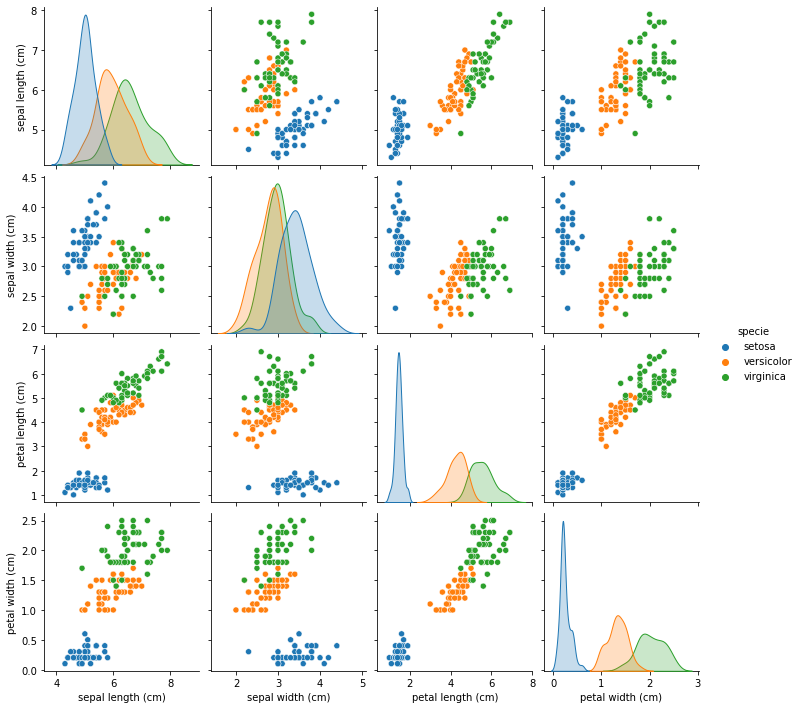

In [24]:
sns.pairplot(data =  dfIris,  hue = "specie")

In [25]:
#Reconstruction des features isolées de la target
X = dfIris.drop("specie", axis=1)
y = dfIris["specie"]

In [26]:
from sklearn.model_selection import train_test_split

In [27]:
#Scinder dataset en 4 (entrainement et test)
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y , test_size = 0.2 , random_state = 1)

In [28]:
#Generer les scores pour chaque configuration de Kfold
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier

In [35]:
#Configurer le kfold avec 5 configurations possible test/train -set
cv  = KFold(5, shuffle = True, random_state = 1)
model = KNeighborsClassifier(n_neighbors = 8)

In [36]:
score_split = cross_val_score(model, Xtrain, ytrain, cv = cv)

In [37]:
score_split

array([1.        , 0.91666667, 0.95833333, 1.        , 0.95833333])

In [38]:
#Score moyen pour les 5 configurations
score_split.mean()

0.9666666666666666

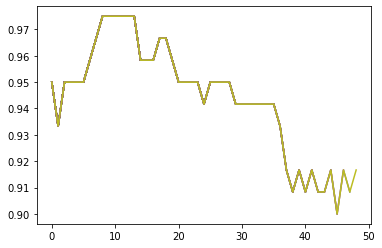

In [44]:
#Variation du nombre de voisins et evalutation de la performance
val_score = []
for k in range (1,50):
    score = cross_val_score(KNeighborsClassifier(n_neighbors=k) , Xtrain, ytrain, cv = cv)
    val_score.append(score.mean())

    import matplotlib.pyplot as plt
    plt.plot(val_score)
    
    #Attention à l'overfitting -> besoin de valider avec validation curve

In [45]:
from sklearn.model_selection import validation_curve

In [46]:
model = KNeighborsClassifier()

In [47]:
k = np.arange(1,50)

In [49]:
#Generation du score d'entrainement et du score de validation
train_score, test_score = validation_curve(model, Xtrain, ytrain, 'n_neighbors', k, cv=cv)

C:\Users\BStorm\anaconda3\lib\site-packages\sklearn\utils\validation.py:67: FutureWarning: Pass param_name=n_neighbors, param_range=[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
 49] as keyword args. From version 0.25 passing these as positional arguments will result in an error
  warnings.warn("Pass {} as keyword args. From version 0.25 "


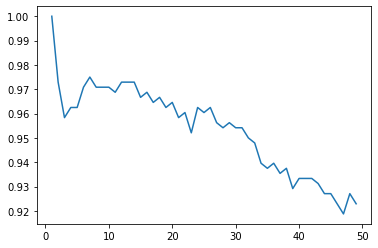

In [57]:
plt.plot(k, train_score.mean(axis=1))

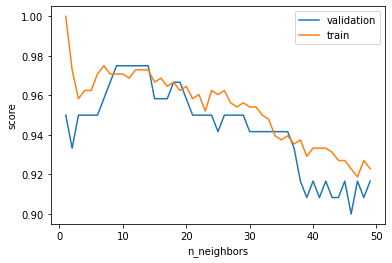

In [58]:
#Comparaison du score de validation avec le score d'entrainement pour s'assurer que l'overfitting est négligeable ->
#-> Différence entre les courbes négligeable -> Overfitting acceptable
plt.plot(k, test_score.mean(axis=1) , label = 'validation')
plt.plot(k, train_score.mean(axis=1) , label = 'train')

plt.ylabel('score')
plt.xlabel('n_neighbors')

plt.legend()
    

In [59]:
#Methode automatique d'optimisation des hyperparamètres

In [65]:
from sklearn.model_selection import GridSearchCV

#Etablir la grille de paramètres
param_grid = {'n_neighbors' : np.arange(1,30),
             'metric' : ['euclidean', 'manhattan', 'minkowski']}

In [66]:
#Instancier le gridsearch avec les paramètres
grid = GridSearchCV(KNeighborsClassifier(),param_grid,cv=cv)

In [67]:
grid

GridSearchCV(cv=KFold(n_splits=5, random_state=1, shuffle=True),
             estimator=KNeighborsClassifier(),
             param_grid={'metric': ['euclidean', 'manhattan', 'minkowski'],
                         'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29])})

In [68]:
#Entrainement du modèle

In [69]:
grid.fit(Xtrain, ytrain)

GridSearchCV(cv=KFold(n_splits=5, random_state=1, shuffle=True),
             estimator=KNeighborsClassifier(),
             param_grid={'metric': ['euclidean', 'manhattan', 'minkowski'],
                         'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29])})

In [70]:
#Recuperer le meilleur estimator
grid.best_estimator_

KNeighborsClassifier(metric='euclidean', n_neighbors=9)

In [71]:
#Recuperer les meilleur score
grid.best_score_

0.975

In [72]:
model = grid.best_estimator_

In [75]:
#Validation avec les données de test
model.score(Xtest, ytest)

0.9666666666666667

In [76]:
#Estimer le gain de perf avec l'augmentation de la quantité de données

In [77]:
from sklearn.model_selection import learning_curve

In [78]:
train_size, train_score, val_score = learning_curve(model, Xtrain, ytrain, train_sizes = np.linspace(0.2, 1,5), cv =cv)

In [80]:
print(train_score)

[[0.89473684 1.         0.89473684 0.78947368 0.73684211]
 [1.         0.97368421 1.         0.97368421 1.        ]
 [0.98245614 0.98245614 1.         0.98245614 0.96491228]
 [0.97368421 0.97368421 0.97368421 0.94736842 0.96052632]
 [0.96875    0.96875    0.97916667 0.96875    0.96875   ]]


In [81]:
train_size

array([19, 38, 57, 76, 96])

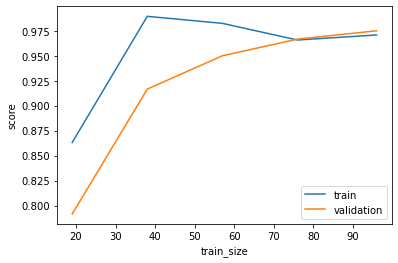

In [82]:
plt.plot(train_size, train_score.mean(axis=1), label = 'train')
plt.plot(train_size, val_score.mean(axis=1), label = 'validation')

plt.ylabel('score')
plt.xlabel('train_size')

plt.legend()